# 02. Edge Detection

목표는 색칠 경계로 사용할 선을 추출하고, 흰 배경과 검은 선 형태의 컬러링북 선화를 만드는 것입니다.

비교 알고리즘:

- Sobel: x/y 방향 밝기 변화량을 계산합니다.
- Laplacian: 2차 미분 기반으로 급격한 변화 지점을 찾습니다.
- Canny: 노이즈 제거, 그래디언트, 비최대 억제, 이중 임계값을 함께 사용하는 대표적인 경계 추출 방식입니다.
- Hybrid Color Boundary: Canny가 놓치는 비슷한 밝기의 색상 경계를 보완합니다.

최종 기본 알고리즘은 Canny에 색상 라벨 경계를 합친 Hybrid 방식입니다.

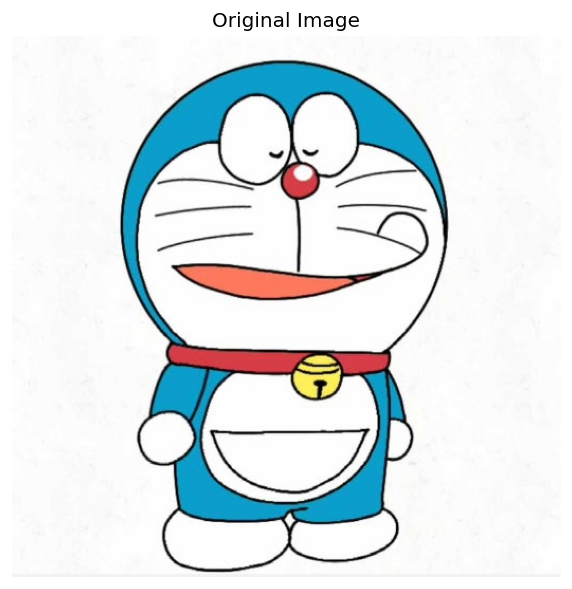

In [54]:
#Kernel → Restart & Run All 로 처음부터 실행하세요
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np


# 공통 함수가 들어 있는 src 폴더를 import 경로에 추가합니다.
sys.path.append("src")
import importlib
import coloringbook_utils as coloringbook_utils
importlib.reload(coloringbook_utils)
from coloringbook_utils import *

# 결과 저장 폴더(outputs)와 샘플 입력 폴더(data)를 생성합니다.
ensure_dirs()
plt.rcParams["figure.dpi"] = 120

# 직접 사용할 이미지가 있으면 여기에 경로를 넣으세요.
# 예: IMAGE_PATH = "../data/flowers.jpg"
IMAGE_PATH = "../server/data/doraemong.jpeg"
if not IMAGE_PATH or not os.path.exists(IMAGE_PATH):
    print(f"WARNING: '{IMAGE_PATH}' not found, using built-in sample image instead.")
    IMAGE_PATH = None

try:
    image = load_image(IMAGE_PATH)
except FileNotFoundError as exc:
    print(f"WARNING: {exc}; using built-in sample image instead.")
    image = load_image(None)

show_images([("Original Image", image)], cols=1, figsize=(5, 5))

## 경계 추출 비교

먼저 K-Means로 색상을 단순화한 뒤 경계를 추출하면 원본의 작은 질감 노이즈가 줄어듭니다.

In [ ]:
import cv2
import numpy as np

# 경계선 추출 전에 색상을 단순화하면 원본 텍스처 노이즈가 줄어듭니다.
K = 10
# Use existing helper if available, otherwise fall back to OpenCV k-means
if callable(globals().get("kmeans_quantization_with_labels")):
    quantized, palette, label_map = kmeans_quantization_with_labels(image, K)
else:
    Z = image.reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)
    _, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    centers = np.clip(centers, 0, 255).astype(np.uint8)
    quantized = centers[labels.flatten()].reshape(image.shape)
    label_map = labels.reshape(image.shape[:2]).astype(np.int32)
    palette = centers

# Sobel: x/y 방향 밝기 변화량을 이용해 경계를 찾습니다.
(sobel, sobel_time) = timed_call(sobel_edges, quantized, 65)

# Laplacian: 2차 미분으로 급격한 밝기 변화를 찾습니다.
(laplacian, lap_time) = timed_call(laplacian_edges, quantized, 25)

# Canny: 노이즈 제거, 비최대 억제, 이중 임계값을 사용하는 기본 선택 알고리즘입니다.
(canny, canny_time) = timed_call(canny_edges, quantized, 60, 150)

# Color Boundary: K-Means 대표 색상 라벨이 바뀌는 지점을 경계로 추가합니다.
# 밝기는 비슷하지만 색상이 다른 겹친 영역을 분리하는 데 중요합니다.
(hybrid, hybrid_time) = timed_call(hybrid_canny_color_edges, quantized, 60, 150, label_map)

# Opening은 작은 점 노이즈 제거, Closing은 끊긴 선 연결에 사용합니다.
sobel_clean = clean_edges(sobel, open_iter=1, close_iter=1, thickness=1)
lap_clean = clean_edges(laplacian, open_iter=1, close_iter=1, thickness=1)
canny_clean = clean_edges(canny, open_iter=0, close_iter=1, thickness=2)
hybrid_clean = clean_edges(hybrid, open_iter=0, close_iter=1, thickness=1)

save_image_rgb("flowersoutput/02_sobel_lines.png", coloring_line_image(sobel_clean))
save_image_rgb("flowersoutput/02_laplacian_lines.png", coloring_line_image(lap_clean))
save_image_rgb("flowersoutput/02_canny_lines.png", coloring_line_image(canny_clean))
save_image_rgb("flowersoutput/02_hybrid_color_boundary_lines.png", coloring_line_image(hybrid_clean))

show_images([
    ("Quantized Input", quantized),
    (f"Sobel density={edge_density(sobel_clean):.3f}", coloring_line_image(sobel_clean)),
    (f"Laplacian density={edge_density(lap_clean):.3f}", coloring_line_image(lap_clean)),
    (f"Canny density={edge_density(canny_clean):.3f}", coloring_line_image(canny_clean)),
    (f"Hybrid density={edge_density(hybrid_clean):.3f}", coloring_line_image(hybrid_clean)),
], cols=2, figsize=(11, 10), cmap="gray", save_path="flowersoutput/02_edge_compare.png")

## Contour 기반 경계선 추출
Bilateral Filter와 Adaptive Threshold를 조합하여 컨투어 기반 경계선을 추출합니다.

- **Bilateral Filter**: 색상 경계는 유지하면서 내부 노이즈를 제거합니다.
- **Adaptive Threshold**: 전체가 아닌 지역별 밝기를 기준으로 이진화하여 조명 변화에 강합니다.
- **Morphology Close**: 끊긴 선을 연결하여 닫힌 영역을 만듭니다.
- **Contour 추출**: 경계선을 컨투어로 검출한 뒤 흰 배경에 검은 선으로 그립니다. 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Contour / Segmentation Pipeline
# Based on EXISTING image
# =========================================================

# Check image

print(type(image))

# Resize
resized = cv2.resize(
    image,
    (800, 600)
)

# Gray
gray = cv2.cvtColor(
    resized,
    cv2.COLOR_RGB2GRAY
)

# Bilateral Filter
smooth = cv2.bilateralFilter(
    gray,
    9,
    75,
    75
)

# Adaptive Threshold
bw = cv2.adaptiveThreshold(
    smooth,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15,
    4
)

# Morphology
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3,3)
)

bw = cv2.morphologyEx(
    bw,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1



)

contours, hierarchy = cv2.findContours(
    bw,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

# White Canvas
contour_img = np.ones_like(gray) * 255

# Draw Contours
cv2.drawContours(
    contour_img,
    contours,
    -1,
    0,
    1
)
# ---------------------------------------------------------
# Connect Broken Lines
# ---------------------------------------------------------

# ---------------------------------------------------------
# Connect Broken Lines
# ---------------------------------------------------------

# Invert
temp = 255 - contour_img

# Small connection kernel
connect_kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (2,2)
)

# Connect lines
temp = cv2.morphologyEx(
    temp,
    cv2.MORPH_CLOSE,
    connect_kernel,
    iterations=1
)

# Invert back
contour_img = 255 - temp

# Display
# ---------------------------------------------------------
plt.figure(figsize=(12,6))

# Original
plt.subplot(1,2,1)

plt.imshow(resized)

plt.title("Original")

plt.axis("off")


# Final Contour
plt.subplot(1,2,2)

plt.imshow(contour_img, cmap='gray')

plt.title("Contour Result")

plt.axis("off")


plt.tight_layout()

plt.show()

## 선 두께와 Morphology 조절

`thickness`, `open_iter`, `close_iter` 값을 바꾸면 번호 삽입과 색칠 난이도에 맞춰 선을 조절할 수 있습니다.

In [ ]:
variants = []
for thickness in [1, 2, 3]:
    # thickness가 커질수록 선은 잘 보이지만 색칠 가능한 흰 영역은 줄어듭니다.
    adjusted = clean_edges(hybrid, open_iter=0, close_iter=1, thickness=thickness)
    variants.append((f"Hybrid thickness={thickness}", coloring_line_image(adjusted)))
    save_image_rgb(f"flowersoutput/02_hybrid_thickness_{thickness}.png", coloring_line_image(adjusted))

show_images(variants, cols=3, figsize=(13, 4), cmap="gray", save_path="flowersoutput/02_thickness_compare.png")

## 성능 비교 표

Edge Density는 전체 픽셀 중 경계 픽셀이 차지하는 비율입니다. 너무 낮으면 선이 끊기고, 너무 높으면 색칠 공간이 좁아집니다.

In [ ]:
edge_rows = [
    {"algorithm": "Sobel", "runtime_sec": sobel_time, "edge_density": edge_density(sobel_clean), "hci_note": "두꺼운 변화 감지, 질감 노이즈 주의"},
    {"algorithm": "Laplacian", "runtime_sec": lap_time, "edge_density": edge_density(lap_clean), "hci_note": "세부 변화 민감, 작은 노이즈 많음"},
    {"algorithm": "Canny", "runtime_sec": canny_time, "edge_density": edge_density(canny_clean), "hci_note": "선명도와 노이즈 균형 우수"},
    {"algorithm": "Hybrid Color Boundary", "runtime_sec": hybrid_time, "edge_density": edge_density(hybrid_clean), "hci_note": "비슷한 밝기의 색상 경계까지 분리"},
]
print_table(edge_rows)

## 비교 분석

- 선 명확도: Canny가 끊김이 적고 외곽선이 비교적 안정적입니다.
- 노이즈: Laplacian은 작은 밝기 변화에도 민감해 노이즈가 많을 수 있습니다.
- 처리 속도: 세 방법 모두 빠르지만 Sobel/Laplacian이 단순하고 Canny가 약간 더 많은 단계를 가집니다.
- 컬러링북 적합성: Canny + Color Boundary + Closing + 적당한 Dilate 조합이 겹친 색상 영역까지 분리해 가장 적합합니다.

## 최종 결과

🔄 최신 이미지 동기화 성공! 현재 처리 중인 해상도: (512, 519)
💾 새로운 선화 이미지가 성공적으로 저장되었습니다: flowersoutput\02_final_result.png


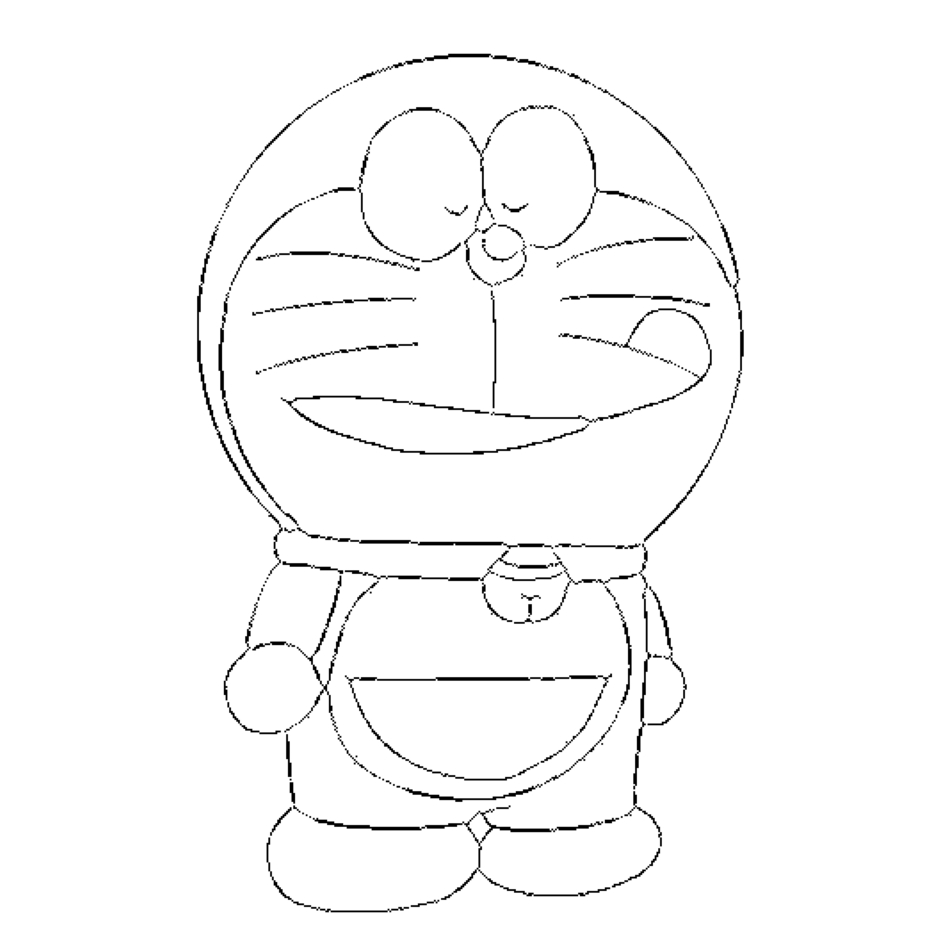

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 【이전 Matplotlib 플롯 캐시 버퍼 강제 비우기】
plt.close('all')

# 【핵심 수정: 최신 로드된 이미지를 실시간으로 반영하여 경로 변경 시 미업데이트 문제 해결】
if 'image' in locals():
    # 최상단 Cell에서 IMAGE_PATH로 읽어온 전역 변수 'image'를 그대로 참조합니다.
    # 컬러(RGB) 이미지인 경우 회색조(Gray)로 변환하고, 이미 회색조인 경우 그대로 복사하여 100% 동기화합니다.
    if len(image.shape) == 3:
        _current_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        _current_gray = image.copy()
    print(f"🔄 최신 이미지 동기화 성공! 현재 처리 중인 해상도: {_current_gray.shape}")
else:
    # 예외 방지: 만약 전역 변수 'image'를 찾을 수 없다면 기존 캐시된 '_gray'를 사용합니다.
    if '_gray' in locals():
        _current_gray = _gray.copy()
        print("⚠️ 전역 'image' 변수를 찾을 수 없어, 기존 캐시된 '_gray' 변수를 사용합니다.")
    else:
        raise NameError("❌ 오류: 이미지 변수를 찾을 수 없습니다. 최상단의 이미지 로드 Cell을 먼저 실행해 주세요!")

# 1. 새로 고침된 최신 회색조 이미지로 양방향 필터(Bilateral Filter) 및 적응형 임계값(Adaptive Threshold) 처리
_smooth  = cv2.bilateralFilter(_current_gray, 9, 75, 75)
_bw      = cv2.adaptiveThreshold(_smooth, 255,
               cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 4)

# 2. 닫기 연산(MORPH_CLOSE): 두께가 있는 이중선 사이의 미세한 틈새를 하나의 '속이 꽉 찬 흰색 굵은 선'으로 완전히 융합합니다.
_kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
_bw      = cv2.morphologyEx(_bw, cv2.MORPH_CLOSE, _kernel, iterations=1)

# 3. 수학적 형태학 기반의 가늘게 하기/세선화(Thinning) 단계
# 실심으로 채워진 굵은 선의 양쪽 끝에서부터 안쪽으로 깎아 들어가, 정중앙에 위치한 1픽셀 두께의 중심 뼈대(단일 선)만 남깁니다.
_skeleton = np.zeros_like(_bw)
_temp = _bw.copy()
_elem = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

while True:
    _open = cv2.morphologyEx(_temp, cv2.MORPH_OPEN, _elem)
    _sub = cv2.subtract(_temp, _open)
    _skeleton = cv2.bitwise_or(_skeleton, _sub)
    _temp = cv2.erode(_temp, _elem)
    if cv2.countNonZero(_temp) == 0:
        break

# 4. 추출된 1픽셀 단일 선 뼈대를 반전시켜 흰색 배경에 검은색 선을 가진 최종 선화 생성
_final_cimg = np.ones_like(_current_gray) * 255
_final_cimg[_skeleton > 0] = 0

# 5. 시각화 및 출력
plt.figure(figsize=(8, 8))
plt.imshow(_final_cimg, cmap="gray")
plt.axis("off")
plt.tight_layout()

# 6. 출력 디렉터리 자동 생성 및 파일 저장
output_dir = "flowersoutput"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
output_path = os.path.join(output_dir, "02_final_result.png")

# 기존 파일이 다른 프로그램에 의해 열려 있어 권한 오류가 발생하는 것을 방지하기 위해 선제적 삭제 시도
if os.path.exists(output_path):
    try:
        os.remove(output_path)
    except:
        pass

plt.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"💾 새로운 선화 이미지가 성공적으로 저장되었습니다: {output_path}")
plt.show()

## 최종 결과 출력

Contour 기반 파이프라인으로 생성한 최종 선화입니다.

- **Bilateral Filter**: 경계는 유지하면서 노이즈를 제거합니다.
- **Adaptive Threshold**: 지역적 밝기 변화에 강한 이진화를 적용합니다.
- **Contour 추출**: 경계선을 컨투어로 검출하여 흰 배경에 검은 선으로 그립니다.